In [90]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/' 

whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc')
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
data=data.isel(time=np.arange(0,140+1))

In [ ]:
########################################################################

In [ ]:
#Vertical Velocity W

In [76]:
Ny=len(data['yh'])

tind=33 #TESTING
times=np.arange(2,len(data['time'])-2)
# for tind in times:

In [80]:
#look (-1 km, CL, +1 km) at times (10 mins before, CL time, 10 mins after)
before_list,during_list,after_list=[],[],[]

for yind in range(Ny):
    CL=whereCL['maxconv_x'].isel(z=3,time=t,y=yind).values 
    CL_x=np.where(CL!=-1)
    for xind in CL_x[0]:
        xrange=slice(xind-1,xind+1+1)
        
        #before
        trange=slice(tind-2,tind-1+1)
        before=data['w'].isel(zf=3,time=trange,xh=xrange,yh=yind).mean(dim=('xh','time')).item() #possibly need to interpolate xh 
        before_list.append(before)
        
        #during        
        trange=tind
        during=data['w'].isel(zf=3,time=trange,xh=xrange,yh=yind).mean(dim=('xh')).item()
        during_list.append(during)
        
        #after
        trange=slice(tind+1,tind+2+1)
        after=data['w'].isel(zf=3,time=trange,xh=xrange,yh=yind).mean(dim=('xh','time')).item()
        after_list.append(after)
        
    # if yind==5: break #TESTING


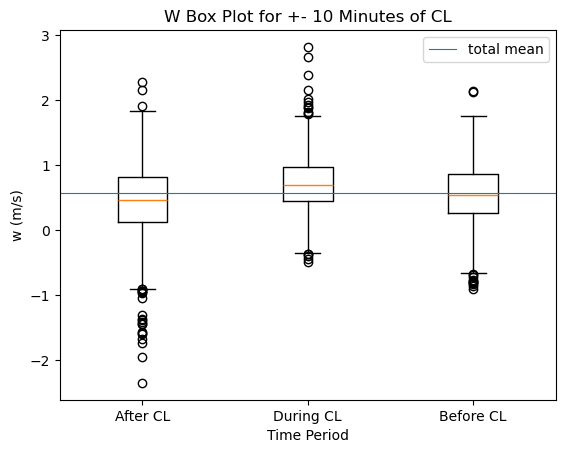

In [89]:
lists = [after_list, during_list, before_list]

# Create the box plot
plt.boxplot(lists, labels=['After CL', 'During CL', 'Before CL'])

# Add labels and title
plt.xlabel('Time Period')
plt.ylabel('w (m/s)')
plt.title('W Box Plot for +- 10 Minutes of CL')

mean_after = np.mean(after_list)
mean_during = np.mean(during_list)
mean_before = np.mean(before_list)

plt.axhline(np.mean([mean_before,mean_during,mean_after]),linewidth=0.8,label='total mean')
plt.legend()

In [ ]:
########################################################################

In [ ]:
#U

In [109]:
Ny=len(data['yh'])

tind=33 #TESTING
times=np.arange(2,len(data['time'])-2)
# for tind in times:

In [111]:
#look (-1 km, CL, +1 km) at times (10 mins before, CL time, 10 mins after)
before_list,during_list,after_list=[],[],[]

for yind in range(Ny):
    CL=whereCL['maxconv_x'].isel(z=3,time=t,y=yind).values 
    CL_x=np.where(CL!=-1)
    for xind in CL_x[0]:
        xrange=slice(xind-1,xind+1+1)
        
        #before
        trange=slice(tind-2,tind-1+1)
        before=data['u'].isel(zh=2,time=trange,xf=xrange,yh=yind).mean(dim=('xf','time')).item()
        before_list.append(before)
        
        #during        
        trange=tind
        during=data['u'].isel(zh=2,time=trange,xf=xrange,yh=yind).mean(dim=('xf')).item()
        during_list.append(during)
        
        #after
        trange=slice(tind+1,tind+2+1)
        after=data['u'].isel(zh=2,time=trange,xf=xrange,yh=yind).mean(dim=('xf','time')).item()
        after_list.append(after)
        
    # if yind==5: break #TESTING


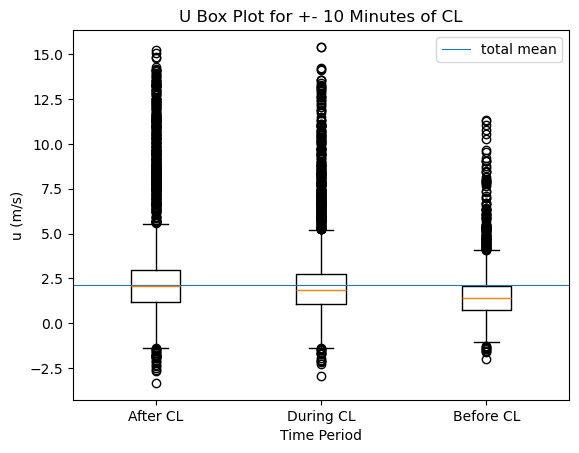

In [112]:
lists = [after_list, during_list, before_list]

# Create the box plot
plt.boxplot(lists, labels=['After CL', 'During CL', 'Before CL'])

# Add labels and title
plt.xlabel('Time Period')
plt.ylabel('u (m/s)')
plt.title('U Box Plot for +- 10 Minutes of CL')

mean_after = np.mean(after_list)
mean_during = np.mean(during_list)
mean_before = np.mean(before_list)

plt.axhline(np.mean([mean_before,mean_during,mean_after]),linewidth=0.8,label='total mean')
plt.legend()

In [ ]:
################################################################################################################################################

In [96]:
#QV

In [114]:
Ny=len(data['yh'])

tind=33 #TESTING
times=np.arange(2,len(data['time'])-2)
# for tind in times:

In [115]:
#look (-1 km, CL, +1 km) at times (10 mins before, CL time, 10 mins after)
before_list,during_list,after_list=[],[],[]
################################################################################################################################################
for yind in range(Ny):
    CL=whereCL['maxconv_x'].isel(z=3,time=t,y=yind).values 
    CL_x=np.where(CL!=-1)
    for xind in CL_x[0]:
        xrange=slice(xind-1,xind+1+1)
        
        #before
        trange=slice(tind-2,tind-1+1)
        before=data['qv'].isel(zh=2,time=trange,xh=xrange,yh=yind).mean(dim=('xh','time')).item()*1000
        before_list.append(before)
        
        #during        
        trange=tind
        during=data['qv'].isel(zh=2,time=trange,xh=xrange,yh=yind).mean(dim=('xh')).item()*1000
        during_list.append(during)
        
        #after
        trange=slice(tind+1,tind+2+1)
        after=data['qv'].isel(zh=2,time=trange,xh=xrange,yh=yind).mean(dim=('xh','time')).item()*1000
        after_list.append(after)
        
    # if yind==5: break #TESTING


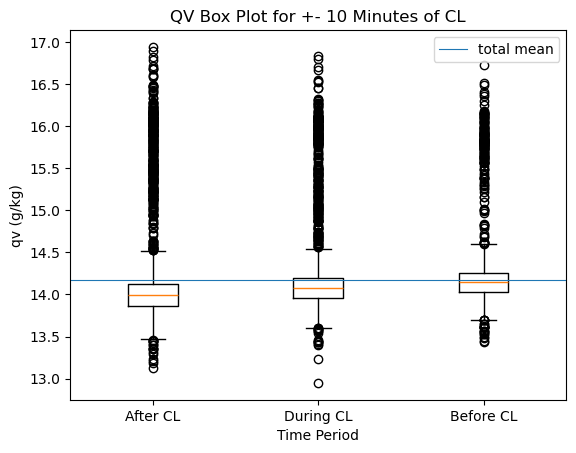

In [116]:
lists = [after_list, during_list, before_list]

# Create the box plot
plt.boxplot(lists, labels=['After CL', 'During CL', 'Before CL'])

# Add labels and title
plt.xlabel('Time Period')
plt.ylabel('qv (g/kg)')
plt.title('QV Box Plot for +- 10 Minutes of CL')

mean_after = np.mean(after_list)
mean_during = np.mean(during_list)
mean_before = np.mean(before_list)

# Plot horizontal lines at the mean of each list
# plt.axhline(y=mean_before, color='k', linestyle='--', xmin=0.05, xmax=0.32, label='Mean Before')
# plt.axhline(y=mean_during, color='b', linestyle='--', xmin=0.35, xmax=0.65, label='Mean During')
# plt.axhline(y=mean_after, color='g', linestyle='--', xmin=0.68, xmax=0.95, label='Mean After')
plt.axhline(np.mean([mean_before,mean_during,mean_after]),linewidth=0.8,label='total mean')
plt.legend()

In [ ]:
################################################################################################################################################

In [ ]:
#Th

In [123]:
Ny=len(data['yh'])

tind=33 #TESTING
times=np.arange(2,len(data['time'])-2)
# for tind in times:

In [124]:
#look (-1 km, CL, +1 km) at times (10 mins before, CL time, 10 mins after)
before_list,during_list,after_list=[],[],[]
################################################################################################################################################
for yind in range(Ny):
    CL=whereCL['maxconv_x'].isel(z=3,time=t,y=yind).values 
    CL_x=np.where(CL!=-1)
    for xind in CL_x[0]:
        xrange=slice(xind-1,xind+1+1)
        
        #before
        trange=slice(tind-2,tind-1+1)
        before=data['th'].isel(zh=2,time=trange,xh=xrange,yh=yind).mean(dim=('xh','time')).item()
        before_list.append(before)
        
        #during        
        trange=tind
        during=data['th'].isel(zh=2,time=trange,xh=xrange,yh=yind).mean(dim=('xh')).item()
        during_list.append(during)
        
        #after
        trange=slice(tind+1,tind+2+1)
        after=data['th'].isel(zh=2,time=trange,xh=xrange,yh=yind).mean(dim=('xh','time')).item()
        after_list.append(after)
        
    # if yind==5: break #TESTING


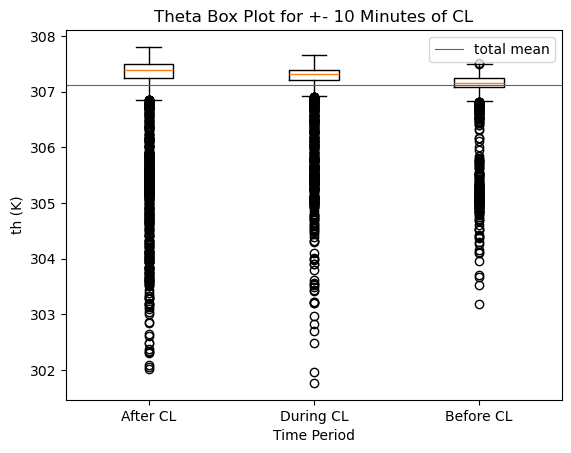

In [125]:
lists = [after_list, during_list, before_list]

# Create the box plot
plt.boxplot(lists, labels=['After CL', 'During CL', 'Before CL'])

# Add labels and title
plt.xlabel('Time Period')
plt.ylabel('th (K)')
plt.title('Theta Box Plot for +- 10 Minutes of CL')

mean_after = np.mean(after_list)
mean_during = np.mean(during_list)
mean_before = np.mean(before_list)

# Plot horizontal lines at the mean of each list
# plt.axhline(y=mean_before, color='k', linestyle='--', xmin=0.05, xmax=0.32, label='Mean Before')
# plt.axhline(y=mean_during, color='b', linestyle='--', xmin=0.35, xmax=0.65, label='Mean During')
# plt.axhline(y=mean_after, color='g', linestyle='--', xmin=0.68, xmax=0.95, label='Mean After')
plt.axhline(np.mean([mean_before,mean_during,mean_after]),linewidth=0.8,label='total mean')
plt.legend()

In [ ]:
################################################################################################################################################

In [ ]:
#Convergence

In [147]:
# finding SBZ CLs (seperate from LBZ CLs and CP CLs)
def get_2dtime_data(data,varname,tlev,zlev):
    cloud_var=data[varname].isel(time=tlev,zh=zlev).values
    return cloud_var
def get_3dtime_data(data,varname,tlev):
    cloud_var=data[varname].isel(time=tlev).values
    return cloud_var

#Function for taking x and y derivatives (Gradient)
def cd2d(f,dx,dy): #size not compatible, cant calculate adjacent gradient
    ddx = (
            f[:,:, 1:  ]
            -
            f[:,:, 0:-1]
        ) / (
        2 * dx
    )
    
    ddy = (
        f[:,1:, :]
        -
        f[:,0:-1, :]
    ) / (
        2 * dy
    )
    
    return ddx, ddy

def convergence(t):
    dx=np.round(data['xf'][1]-data['xf'][0],2).item()*1000;dy=dx #gets the dx,dy in meters (0.25m in this case)
    u=get_3dtime_data(data,'u',t)       
    v=get_3dtime_data(data,'v',t)  
    [dudx,dudy]=cd2d(u,dx,dy)
    [dvdx,dvdy]=cd2d(v,dx,dy)
    conv = -(dudx + dvdy)
    conv=conv[2]
    return conv

In [146]:
Ny=len(data['yh'])

tind=33 #TESTING
times=np.arange(2,len(data['time'])-2)
# for tind in times:

(100, 512)

In [164]:
#look (-1 km, CL, +1 km) at times (10 mins before, CL time, 10 mins after)
before_list,during_list,after_list=[],[],[]
################################################################################################################################################
for yind in range(Ny):
    if np.mod(yind,10)==0: print(f'current y ind: {yind}')
        
    CL=whereCL['maxconv_x'].isel(z=3,time=t,y=yind).values 
    CL_x=np.where(CL!=-1)
    for xind in CL_x[0]:
        xrange=slice(xind-1,xind+1+1)
        
        #before
        trange=np.arange(tind-2,tind-1+1)
        before=0
        for t in trange:
            before+=np.sum(convergence(t)[yind,xrange]) 
        before/=2
        before_list.append(before)
        
        #during        
        trange=tind
        during=np.sum(convergence(t)[yind,xrange]) 
        during_list.append(during)
        
        #after
        trange=np.arange(tind+1,tind+2+1)
        after=0
        for t in trange:
            after+=np.sum(convergence(t)[yind,xrange]) 
        after/=2
        after_list.append(after)
        
    # if yind==5: break #TESTING


current y ind: 0
current y ind: 10
current y ind: 20
current y ind: 30
current y ind: 40
current y ind: 50
current y ind: 60
current y ind: 70
current y ind: 80
current y ind: 90


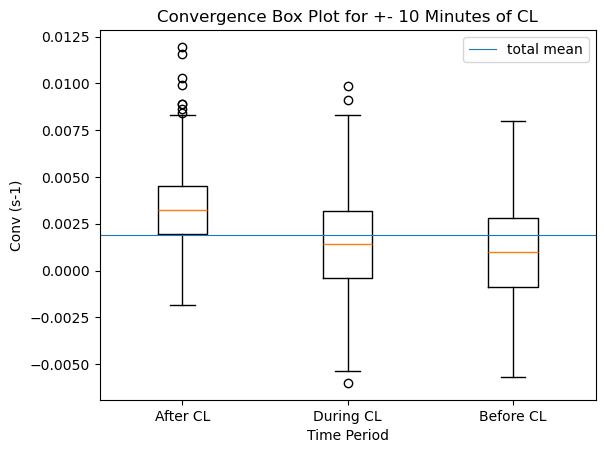

In [165]:
lists = [after_list, during_list, before_list]

# Create the box plot
plt.boxplot(lists, labels=['After CL', 'During CL', 'Before CL'])

# Add labels and title
plt.xlabel('Time Period')
plt.ylabel('Conv (s-1)')
plt.title('Convergence Box Plot for +- 10 Minutes of CL')

mean_after = np.mean(after_list)
mean_during = np.mean(during_list)
mean_before = np.mean(before_list)

# Plot horizontal lines at the mean of each list
# plt.axhline(y=mean_before, color='k', linestyle='--', xmin=0.05, xmax=0.32, label='Mean Before')
# plt.axhline(y=mean_during, color='b', linestyle='--', xmin=0.35, xmax=0.65, label='Mean During')
# plt.axhline(y=mean_after, color='g', linestyle='--', xmin=0.68, xmax=0.95, label='Mean After')
plt.axhline(np.mean([mean_before,mean_during,mean_after]),linewidth=0.8,label='total mean')
plt.legend()